# La galaxia desaparecida que ayudó a construir la Vía Láctea

Hace unos 11.800 millones de años, cuando el universo apenas tenía 2.000 millones, una galaxia enana se fusionó con la joven Vía Láctea. La galaxia dejó de existir como objeto independiente, pero una parte de sus estrellas continúa entre nosotros.

En este proyecto sitúo el hallazgo de **Low-energy-Kraken-Heracles (LKH)** dentro de una cronología sencilla para responder una pregunta: **¿cuánto cambia esta fusión nuestra imagen de la historia temprana de la Vía Láctea?**

El estudio original analizó 39 cúmulos globulares mediante sus edades, metalicidades y movimientos. Este notebook no reproduce aquel modelo astrofísico; utiliza las cifras publicadas para construir un análisis descriptivo y explicar la escala temporal del descubrimiento.

## Preparación del análisis

Importo las librerías que utilizaré para cargar, transformar y visualizar los datos.

In [1]:
# importo las librerías necesarias
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# configuro el estilo general de las visualizaciones
sns.set_theme(
    style="whitegrid",
    palette="deep"
)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

## Carga del dataset

Trabajo con una cronología mínima construida a partir del artículo científico y del resumen publicado por NASA. Cada fila representa un acontecimiento que ayuda a situar la fusión con LKH.

La variable `antiguedad_gyr` indica cuántos miles de millones de años han pasado desde cada evento. `edad_universo_gyr` representa la edad aproximada que tenía el universo en aquel momento.

In [2]:
# defino la ruta del dataset
ruta_datos = Path("datos_historia_via_lactea.csv")

# cargo la cronología
df = pd.read_csv(ruta_datos)

# compruebo el tamaño del dataset
print(
    f"el dataset contiene {df.shape[0]} eventos "
    f"y {df.shape[1]} variables"
)

# reviso las primeras observaciones
display(df.head())

el dataset contiene 6 eventos y 6 variables


,evento,antiguedad_gyr,edad_universo_gyr,tipo,nota,fuente
0,Big Bang,13.8,0.0,referencia,Inicio de la escala temporal,https://science.nasa.gov/universe/overview/
1,Fusión con LKH,11.8,2.0,fusion,Primera gran fusión identificada mediante esta secuencia de cúmulos globulares,https://doi.org/10.1038/s41550-026-02931-5
2,Fusión con Gaia-Sausage-Enceladus,10.0,3.8,fusion,Gran episodio de acreción usado como referencia por el estudio,https://science.nasa.gov/missions/hubble/hubble-solves-merger-mystery-from-milky-ways-early-years/
3,Inicio de la fusión con Sagitario,6.0,7.8,fusion,Proceso iniciado hace más de 6 mil millones de años y todavía activo,https://science.nasa.gov/missions/hubble/hubble-solves-merger-mystery-from-milky-ways-early-years/
4,Formación del Sistema Solar,4.6,9.2,referencia,Referencia temporal aproximada,https://science.nasa.gov/solar-system/


### Primera inspección de los datos

El dataset es pequeño porque no pretende reunir toda la historia de la Vía Láctea. Incluye únicamente las referencias necesarias para comparar LKH con Gaia-Sausage-Enceladus, la fusión de Sagitario, la formación del Sistema Solar y la edad actual del universo.

In [3]:
# compruebo los duplicados y los valores ausentes
print("filas duplicadas:", df.duplicated().sum())
print("valores ausentes:", df.isna().sum().sum())

# reviso los tipos de datos
display(
    df.dtypes
    .rename("tipo de dato")
    .to_frame()
)

filas duplicadas: 0
valores ausentes: 0


,tipo de dato
evento,str
antiguedad_gyr,float64
edad_universo_gyr,float64
tipo,str
nota,str
fuente,str


In [4]:
# ordeno los eventos desde el más antiguo hasta el presente
cronologia = (
    df
    .sort_values("antiguedad_gyr", ascending=False)
    .reset_index(drop=True)
)

# selecciono las columnas más útiles para la lectura
display(
    cronologia[
        [
            "evento",
            "antiguedad_gyr",
            "edad_universo_gyr",
            "tipo"
        ]
    ]
)

,evento,antiguedad_gyr,edad_universo_gyr,tipo
0,Big Bang,13.8,0.0,referencia
1,Fusión con LKH,11.8,2.0,fusion
2,Fusión con Gaia-Sausage-Enceladus,10.0,3.8,fusion
3,Inicio de la fusión con Sagitario,6.0,7.8,fusion
4,Formación del Sistema Solar,4.6,9.2,referencia
5,Actualidad,0.0,13.8,referencia


## Una galaxia encontrada mediante sus fósiles estelares

LKH no fue observada directamente. El equipo estudió 39 cúmulos globulares situados en los 20.000 años luz más internos de la Vía Láctea y encontró tres secuencias distintas de edad y metalicidad:

1. una asociada a la propia Vía Láctea;
2. otra vinculada a Gaia-Sausage-Enceladus;
3. una tercera población intermedia atribuida a una fusión anterior.

El modelo estima que LKH contenía aproximadamente 500 millones de masas solares en estrellas. Estas cifras resumen la escala de la evidencia, pero no forman un catálogo individual de los 39 cúmulos.

In [5]:
# reúno las principales cifras publicadas sobre el hallazgo
cifras_hallazgo = pd.DataFrame({
    "indicador": [
        "cúmulos globulares analizados",
        "radio de la región estudiada",
        "masa estelar estimada de LKH",
        "adelanto frente a Gaia-Enceladus"
    ],
    "valor": [
        39,
        20_000,
        500_000_000,
        1.8
    ],
    "unidad": [
        "cúmulos",
        "años luz",
        "masas solares",
        "miles de millones de años"
    ],
    "naturaleza": [
        "muestra observada",
        "alcance de la muestra",
        "estimación del modelo",
        "comparación temporal"
    ]
})

# presento las cifras sin mezclar observaciones y estimaciones
display(cifras_hallazgo)

,indicador,valor,unidad,naturaleza
0,cúmulos globulares analizados,39.0,cúmulos,muestra observada
1,radio de la región estudiada,20000.0,años luz,alcance de la muestra
2,masa estelar estimada de LKH,500000000.0,masas solares,estimación del modelo
3,adelanto frente a Gaia-Enceladus,1.8,miles de millones de años,comparación temporal


## Situar LKH en la historia del universo

La escala horizontal representa la edad del universo. Esto evita una lectura confusa de “años antes del presente”: el Big Bang aparece al comienzo y la actualidad al final.

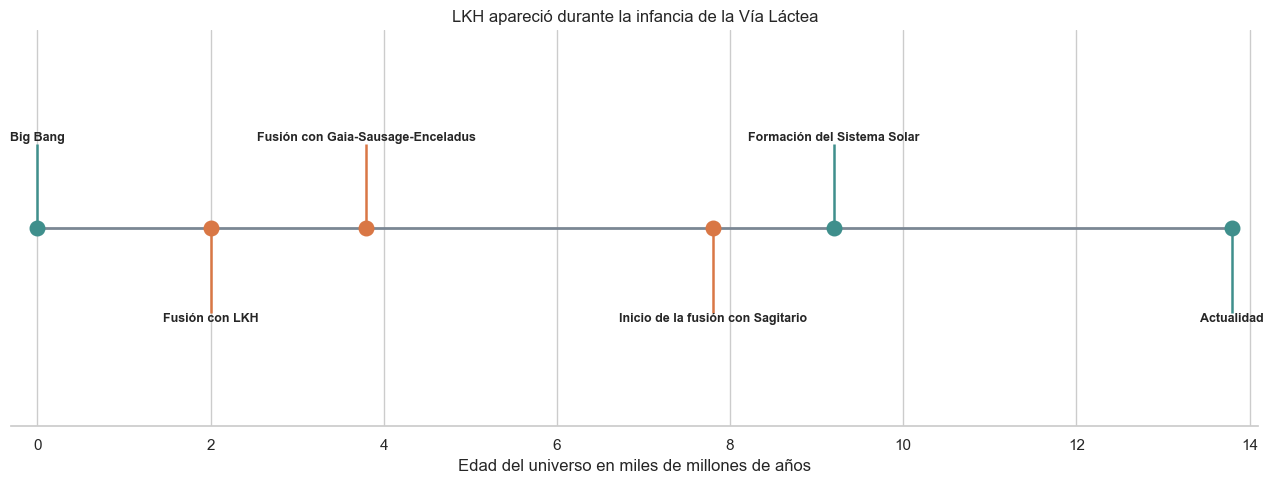

In [7]:
# preparo los eventos que utilizaré en la cronología
eventos_cronologia = cronologia.copy()

# asigno un color según el tipo de acontecimiento
colores_tipo = {
    "fusion": "#d97745",
    "referencia": "#3f8f8c"
}

# creo la figura
fig, ax = plt.subplots(figsize=(13, 5))

# dibujo la línea temporal principal
ax.hlines(
    y=0,
    xmin=0,
    xmax=13.8,
    color="#7b8794",
    linewidth=2
)

# represento cada evento sobre la edad del universo
for indice, fila in eventos_cronologia.iterrows():
    posicion_vertical = 0.32 if indice % 2 == 0 else -0.32

    ax.vlines(
        x=fila["edad_universo_gyr"],
        ymin=0,
        ymax=posicion_vertical,
        color=colores_tipo[fila["tipo"]],
        linewidth=1.8
    )

    ax.scatter(
        fila["edad_universo_gyr"],
        0,
        s=110,
        color=colores_tipo[fila["tipo"]],
        zorder=3
    )

    ax.text(
        fila["edad_universo_gyr"],
        posicion_vertical,
        fila["evento"],
        ha="center",
        va="bottom" if posicion_vertical > 0 else "top",
        fontsize=9,
        weight="bold"
    )

# ajusto el título y los ejes
ax.set(
    title="LKH apareció durante la infancia de la Vía Láctea",
    xlabel="Edad del universo en miles de millones de años",
    xlim=(-0.3, 14.1),
    ylim=(-0.75, 0.75),
    yticks=[]
)

sns.despine(left=True)
plt.tight_layout()
plt.show()

### La primera gran fusión identificada ocurrió muy pronto

La cronología muestra que LKH se incorporó a la Vía Láctea cuando el universo tenía unos 2.000 millones de años. Gaia-Sausage-Enceladus llegó aproximadamente 1.800 millones de años después.

El Sistema Solar todavía tardaría unos 7.200 millones de años en formarse. La comparación ayuda a entender que LKH no pertenece simplemente al pasado de nuestra galaxia, sino a una fase muy temprana de su construcción.

## Medir cuánto cambia el hallazgo la cronología

Calculo tres indicadores descriptivos: la diferencia temporal frente a Gaia-Sausage-Enceladus, la edad relativa del universo y el tiempo transcurrido hasta la formación del Sistema Solar.

In [8]:
# creo un índice para recuperar cada acontecimiento por su nombre
eventos = df.set_index("evento")

# recupero las referencias que necesito para los cálculos
lkh = eventos.loc["Fusión con LKH"]
gaia_enceladus = eventos.loc["Fusión con Gaia-Sausage-Enceladus"]
sistema_solar = eventos.loc["Formación del Sistema Solar"]

# calculo cuánto precedió LKH a Gaia-Enceladus
adelanto_lkh = (
    lkh["antiguedad_gyr"]
    - gaia_enceladus["antiguedad_gyr"]
)

# calculo qué porcentaje de su edad actual tenía el universo
porcentaje_edad_universo = (
    lkh["edad_universo_gyr"]
    / 13.8
    * 100
)

# calculo el tiempo hasta la formación del Sistema Solar
tiempo_hasta_sistema_solar = (
    sistema_solar["edad_universo_gyr"]
    - lkh["edad_universo_gyr"]
)

# reúno los resultados en una tabla
metricas_clave = pd.DataFrame({
    "métrica": [
        "adelanto frente a Gaia-Enceladus",
        "edad relativa del universo",
        "tiempo hasta la formación del Sistema Solar"
    ],
    "valor": [
        f"{adelanto_lkh:.1f} mil millones de años",
        f"{porcentaje_edad_universo:.1f}% de la edad actual",
        f"{tiempo_hasta_sistema_solar:.1f} mil millones de años"
    ]
})

display(metricas_clave)

,métrica,valor
0,adelanto frente a Gaia-Enceladus,1.8 mil millones de años
1,edad relativa del universo,14.5% de la edad actual
2,tiempo hasta la formación del Sistema Solar,7.2 mil millones de años


## Comparación de las fusiones incluidas

La cronología contiene tres episodios de fusión. Comparo su antigüedad para mostrar la distancia que separa LKH de los procesos posteriores.

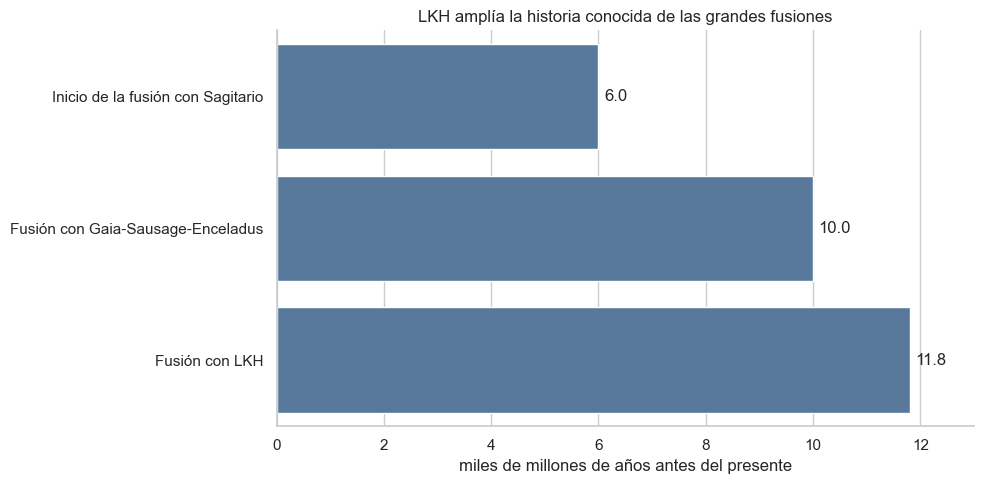

In [9]:
# selecciono únicamente los eventos clasificados como fusiones
fusiones = (
    df.loc[df["tipo"].eq("fusion")]
    .sort_values("antiguedad_gyr")
)

# represento la antigüedad aproximada de cada fusión
fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    data=fusiones,
    x="antiguedad_gyr",
    y="evento",
    color="#4c78a8",
    ax=ax
)

# añado el valor al final de cada barra
for contenedor in ax.containers:
    ax.bar_label(
        contenedor,
        fmt="%.1f",
        padding=4
    )

# ajusto el título y los ejes
ax.set(
    title="LKH amplía la historia conocida de las grandes fusiones",
    xlabel="miles de millones de años antes del presente",
    ylabel="",
    xlim=(0, 13)
)

sns.despine()
plt.tight_layout()
plt.show()

## Conclusiones

El análisis permite resumir el hallazgo en cuatro ideas:

1. **LKH pertenece a una fase muy temprana del universo.** La fusión ocurrió cuando el cosmos tenía aproximadamente el 14,5 % de su edad actual.

2. **El resultado amplía la cronología de la Vía Láctea.** El episodio precede en unos 1.800 millones de años a Gaia-Sausage-Enceladus, la gran fusión antigua utilizada hasta ahora como referencia.

3. **La evidencia procede de fósiles estelares.** Las edades, metalicidades y movimientos de 39 cúmulos globulares permitieron distinguir una población que no encajaba con la Vía Láctea ni con Gaia-Sausage-Enceladus.

4. **Nuestra galaxia creció incorporando material externo desde muy pronto.** La Vía Láctea no se formó como una estructura aislada; su historia incluye fusiones, absorciones y estrellas nacidas en otras galaxias.

## Limitaciones

Este notebook ofrece una lectura descriptiva y presenta varias limitaciones:

- La cronología contiene seis eventos y no representa una historia completa de la Vía Láctea.
- No dispongo del catálogo individual de los 39 cúmulos, por lo que no reproduzco el análisis de edad y metalicidad del estudio.
- La masa de LKH y la fecha de la fusión son estimaciones derivadas de modelos, no mediciones directas de una galaxia intacta.
- El nombre LKH agrupa varias hipótesis anteriores que el nuevo trabajo interpreta como rastros de un mismo episodio.
- Una fusión galáctica es un proceso gradual, no un choque instantáneo entre estrellas.

Por estas razones, el resultado debe interpretarse como **evidencia de una antigua gran fusión**, no como una observación directa del acontecimiento.

### Fuentes

- Massari et al. (2026), [*Evidence of a massive accretion event 1.8 billion years before the Gaia-Sausage-Enceladus merger*](https://doi.org/10.1038/s41550-026-02931-5), *Nature Astronomy*.
- NASA Hubble Mission Team, [*Hubble Solves Merger Mystery From Milky Way’s Early Years*](https://science.nasa.gov/missions/hubble/hubble-solves-merger-mystery-from-milky-ways-early-years/).